In [75]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
# from sklearn.linear_model import LinearRegression

In [76]:

df = pd.read_csv(r"D:\dattu\Data Science\05_machinelearning\ML_Projects\1.Delevery_time_detection\Data\Food_Delivery_Times.csv")
df.head()

,Order_ID,Distance_km,Weather,Traffic_Level,Time_of_Day,Vehicle_Type,Preparation_Time_min,Courier_Experience_yrs,Delivery_Time_min
0,522,7.93,Windy,Low,Afternoon,Scooter,12,1.0,43
1,738,16.42,Clear,Medium,Evening,Bike,20,2.0,84
2,741,9.52,Foggy,Low,Night,Scooter,28,1.0,59
3,661,7.44,Rainy,Medium,Afternoon,Scooter,5,1.0,37
4,412,19.03,Clear,Low,Morning,Bike,16,5.0,68


In [77]:
df.shape #Contains 1000 rows and 9 columns

(1000, 9)

In [78]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Order_ID                1000 non-null   int64  
 1   Distance_km             1000 non-null   float64
 2   Weather                 970 non-null    str    
 3   Traffic_Level           970 non-null    str    
 4   Time_of_Day             970 non-null    str    
 5   Vehicle_Type            1000 non-null   str    
 6   Preparation_Time_min    1000 non-null   int64  
 7   Courier_Experience_yrs  970 non-null    float64
 8   Delivery_Time_min       1000 non-null   int64  
dtypes: float64(2), int64(3), str(4)
memory usage: 70.4 KB


In [79]:
df.isnull().sum() 

Order_ID                   0
Distance_km                0
Weather                   30
Traffic_Level             30
Time_of_Day               30
Vehicle_Type               0
Preparation_Time_min       0
Courier_Experience_yrs    30
Delivery_Time_min          0
dtype: int64

In [80]:
df.describe()

,Order_ID,Distance_km,Preparation_Time_min,Courier_Experience_yrs,Delivery_Time_min
count,1000.000000,1000.000000,1000.000000,970.000000,1000.000000
mean,500.500000,10.059970,16.982000,4.579381,56.732000
std,288.819436,5.696656,7.204553,2.914394,22.070915
min,1.000000,0.590000,5.000000,0.000000,8.000000
25%,250.750000,5.105000,11.000000,2.000000,41.000000
50%,500.500000,10.190000,17.000000,5.000000,55.500000
75%,750.250000,15.017500,23.000000,7.000000,71.000000
max,1000.000000,19.990000,29.000000,9.000000,153.000000


so there are almost 1000 rows and 9 columns and there are some missing data in the dataset. the highest time taken  to delivey is about 153mins and least is about 8mins. the average time taken to delivery is about 56mins. 
weather column contains 30 missing data
Traffic_Level column contains 30 missing data
Time_of_Day  column contains 30 missing data
Courier_Experience_yrs column contains 30 missing data


In [81]:
df["Weather"].value_counts()


Weather
Clear    470
Rainy    204
Foggy    103
Snowy     97
Windy     96
Name: count, dtype: int64

In [82]:
df["Traffic_Level"].value_counts()


Traffic_Level
Medium    390
Low       383
High      197
Name: count, dtype: int64

In [83]:
df["Time_of_Day"].value_counts()

Time_of_Day
Morning      308
Evening      293
Afternoon    284
Night         85
Name: count, dtype: int64

In [84]:
for col in ["Weather", "Traffic_Level", "Time_of_Day"]:
    print(f"\n{col}")
    print(df[col].value_counts())


Weather
Weather
Clear    470
Rainy    204
Foggy    103
Snowy     97
Windy     96
Name: count, dtype: int64

Traffic_Level
Traffic_Level
Medium    390
Low       383
High      197
Name: count, dtype: int64

Time_of_Day
Time_of_Day
Morning      308
Evening      293
Afternoon    284
Night         85
Name: count, dtype: int64


In [85]:
df["Weather"] = df["Weather"].fillna(df["Weather"].mode()[0])

df["Traffic_Level"] = df["Traffic_Level"].fillna(
    df["Traffic_Level"].mode()[0]
)

df["Time_of_Day"] = df["Time_of_Day"].fillna(
    df["Time_of_Day"].mode()[0]
)

.mode() - Finds the most frequent value(s)

[0] -  Takes the first value

In [86]:
df.isnull().sum()

Order_ID                   0
Distance_km                0
Weather                    0
Traffic_Level              0
Time_of_Day                0
Vehicle_Type               0
Preparation_Time_min       0
Courier_Experience_yrs    30
Delivery_Time_min          0
dtype: int64

In [87]:
df["Courier_Experience_yrs"].describe()

count    970.000000
mean       4.579381
std        2.914394
min        0.000000
25%        2.000000
50%        5.000000
75%        7.000000
max        9.000000
Name: Courier_Experience_yrs, dtype: float64

In [88]:
df["Courier_Experience_yrs"] = df["Courier_Experience_yrs"].fillna(
    df["Courier_Experience_yrs"].mean()
)
df.isnull().sum()

Order_ID                  0
Distance_km               0
Weather                   0
Traffic_Level             0
Time_of_Day               0
Vehicle_Type              0
Preparation_Time_min      0
Courier_Experience_yrs    0
Delivery_Time_min         0
dtype: int64

For `Courier_Experience_yrs`, the mean is approximately 4.58 and the median is 5. Since the values are relatively close, the mean can reasonably be used to fill the missing values.

In [89]:
df.columns

Index(['Order_ID', 'Distance_km', 'Weather', 'Traffic_Level', 'Time_of_Day',
       'Vehicle_Type', 'Preparation_Time_min', 'Courier_Experience_yrs',
       'Delivery_Time_min'],
      dtype='str')

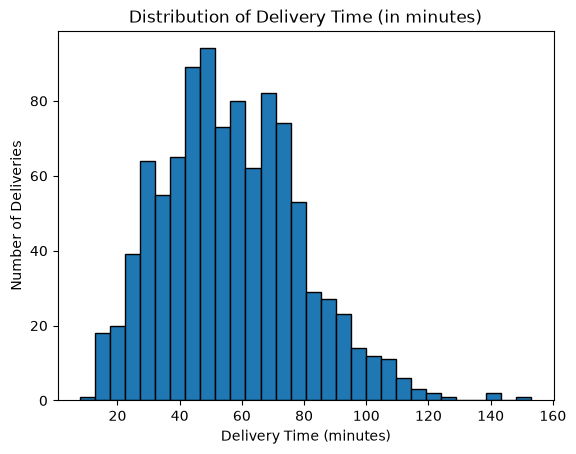

<Figure size 640x480 with 0 Axes>

In [90]:
plt.hist(df["Delivery_Time_min"], bins=30, edgecolor="black")
plt.title("Distribution of Delivery Time (in minutes)")
plt.xlabel("Delivery Time (minutes)")
plt.ylabel("Number of Deliveries")
plt.show()
plt.savefig(r"D:\dattu\Data Science\05_machinelearning\ML_Projects\1.Delevery_time_detection\Outputs\Delivery_Time_Distribution.png")

In [91]:
df.select_dtypes(include=["number"]).columns

Index(['Order_ID', 'Distance_km', 'Preparation_Time_min',
       'Courier_Experience_yrs', 'Delivery_Time_min'],
      dtype='str')

In [92]:
corr = df.select_dtypes(include=["number"]).corr()
corr

,Order_ID,Distance_km,Preparation_Time_min,Courier_Experience_yrs,Delivery_Time_min
Order_ID,1.000000,-0.024483,-0.035100,0.012933,-0.036650
Distance_km,-0.024483,1.000000,-0.009037,-0.007713,0.780998
Preparation_Time_min,-0.035100,-0.009037,1.000000,-0.030353,0.307350
Courier_Experience_yrs,0.012933,-0.007713,-0.030353,1.000000,-0.089066
Delivery_Time_min,-0.036650,0.780998,0.307350,-0.089066,1.000000


Numerical Feature Observations

- `Distance_km` has a strong positive correlation of approximately **0.78** with `Delivery_Time_min`, making it the strongest numerical factor among the available features.
- `Preparation_Time_min` has a moderate positive correlation of approximately **0.31** with `Delivery_Time_min`.
- `Courier_Experience_yrs` has a weak negative correlation of approximately **-0.09** with `Delivery_Time_min`, suggesting that courier experience has a relatively small linear relationship with delivery time.

In [93]:
df.select_dtypes(include=["object"]).columns

C:\Users\NATRAJ\AppData\Local\Temp\ipykernel_11376\2790643224.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  df.select_dtypes(include=["object"]).columns


Index(['Weather', 'Traffic_Level', 'Time_of_Day', 'Vehicle_Type'], dtype='str')

In [94]:
df.groupby("Weather")["Delivery_Time_min"].mean()

Weather
Clear    53.150000
Foggy    59.466019
Rainy    59.794118
Snowy    67.113402
Windy    55.458333
Name: Delivery_Time_min, dtype: float64

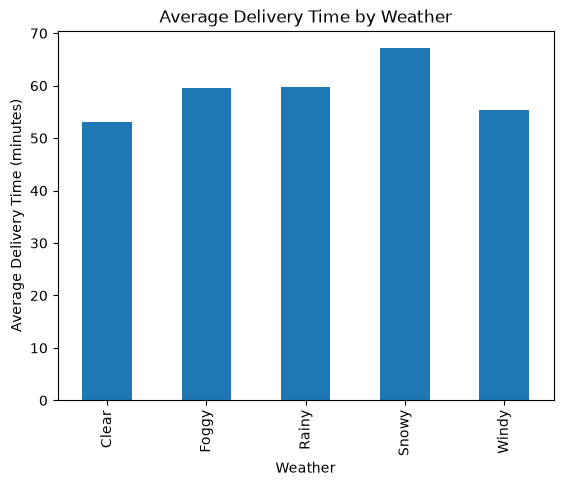

<Figure size 640x480 with 0 Axes>

In [95]:
df.groupby("Weather")["Delivery_Time_min"].mean().plot(kind="bar")

plt.xlabel("Weather")
plt.ylabel("Average Delivery Time (minutes)")
plt.title("Average Delivery Time by Weather")
plt.show()
plt.savefig(r"D:\dattu\Data Science\05_machinelearning\ML_Projects\1.Delevery_time_detection\Outputs\Average_Delivery_Time_by_Weather.png")

Weather vs Average Delivery Time

- Clear weather has the **lowest average delivery time**.
- Snowy weather has a **comparatively higher average delivery time**.
- Rainy and Foggy weather have **similar average delivery times**.
- Windy weather lies between the lower and higher average delivery times.

This suggests that **weather may have an impact on delivery time**.

In [96]:
df.groupby("Traffic_Level")["Delivery_Time_min"].mean()


Traffic_Level
High      64.807107
Low       52.885117
Medium    56.452381
Name: Delivery_Time_min, dtype: float64

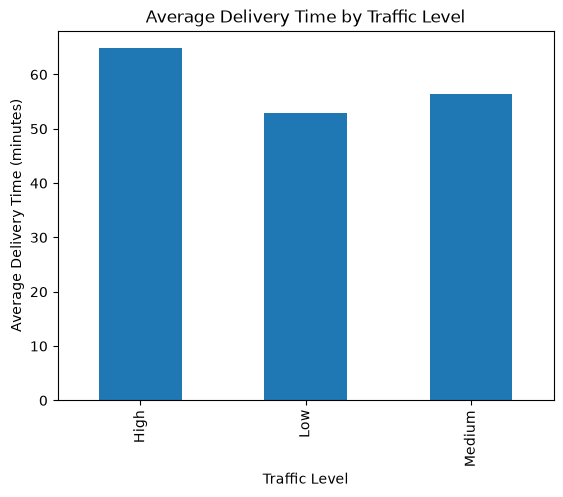

<Figure size 640x480 with 0 Axes>

In [97]:
df.groupby("Traffic_Level")["Delivery_Time_min"].mean().plot(kind="bar")
plt.xlabel("Traffic Level")
plt.ylabel("Average Delivery Time (minutes)")
plt.title("Average Delivery Time by Traffic Level")
plt.show()
plt.savefig(r"D:\dattu\Data Science\05_machinelearning\ML_Projects\1.Delevery_time_detection\Outputs\Average_Delivery_Time_by_Traffic_Level.png")

 Traffic Level vs Average Delivery Time

- High traffic has the **highest average delivery time**.
- Medium and low traffic have comparatively **lower average delivery times**.

This suggests that **traffic level has an important impact on delivery time**, as higher traffic can generally lead to longer delivery durations.

In [98]:
df.groupby("Time_of_Day")["Delivery_Time_min"].mean()

Time_of_Day
Afternoon    56.080986
Evening      57.481229
Morning      57.011834
Night        55.211765
Name: Delivery_Time_min, dtype: float64

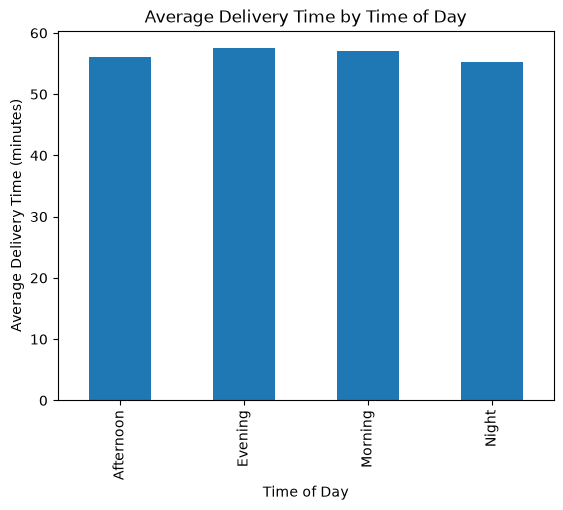

<Figure size 640x480 with 0 Axes>

In [99]:
df.groupby("Time_of_Day")["Delivery_Time_min"].mean().plot(kind="bar")
plt.xlabel("Time of Day")
plt.ylabel("Average Delivery Time (minutes)")
plt.title("Average Delivery Time by Time of Day")
plt.show()
plt.savefig(r"D:\dattu\Data Science\05_machinelearning\ML_Projects\1.Delevery_time_detection\Outputs\Average_Delivery_Time_by_Time_of_Day.png")

Time of Day vs Average Delivery Time

- The average delivery times across different times of the day are very close.
- Evening has the highest average delivery time, while Night has the lowest.
- However, the differences are relatively small, suggesting that `Time_of_Day` may not have a strong relationship with delivery time in this dataset.

In [100]:
df.groupby("Vehicle_Type")["Delivery_Time_min"].mean()

Vehicle_Type
Bike       56.574553
Car        58.200000
Scooter    56.046358
Name: Delivery_Time_min, dtype: float64

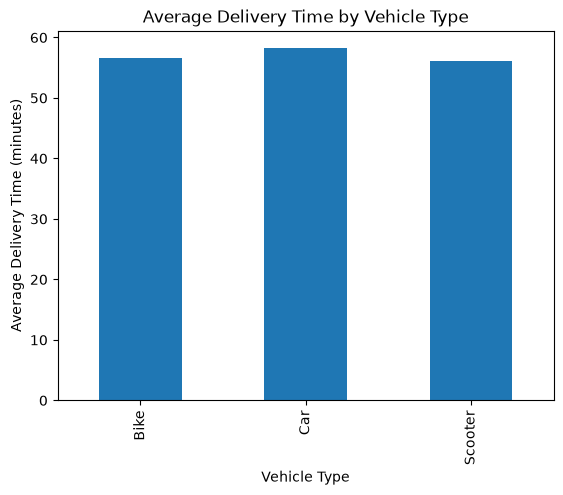

<Figure size 640x480 with 0 Axes>

In [101]:
df.groupby("Vehicle_Type")["Delivery_Time_min"].mean().plot(kind="bar")

plt.xlabel("Vehicle Type")
plt.ylabel("Average Delivery Time (minutes)")
plt.title("Average Delivery Time by Vehicle Type")
plt.show()
plt.savefig(r"D:\dattu\Data Science\05_machinelearning\ML_Projects\1.Delevery_time_detection\Outputs\Average_Delivery_Time_by_Vehicle_Type.png")

 Vehicle Type vs Average Delivery Time

- Car has the highest average delivery time.
- Bike and Scooter have slightly lower and very similar average delivery times.
- The differences are relatively small, so `Vehicle_Type` may have a limited impact on delivery time compared with features such as `Distance_km` and `Traffic_Level`.

In [102]:
#ML Model building starts
X = df.drop(columns=["Order_ID", "Delivery_Time_min"])

y = df["Delivery_Time_min"]

In [103]:
X.head()

,Distance_km,Weather,Traffic_Level,Time_of_Day,Vehicle_Type,Preparation_Time_min,Courier_Experience_yrs
0,7.93,Windy,Low,Afternoon,Scooter,12,1.0
1,16.42,Clear,Medium,Evening,Bike,20,2.0
2,9.52,Foggy,Low,Night,Scooter,28,1.0
3,7.44,Rainy,Medium,Afternoon,Scooter,5,1.0
4,19.03,Clear,Low,Morning,Bike,16,5.0


In [104]:
y.head()

0    43
1    84
2    59
3    37
4    68
Name: Delivery_Time_min, dtype: int64

In [105]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [106]:
print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)
print("X_test shape:", X_test.shape)
print("y_test shape:", y_test.shape)


X_train shape: (800, 7)
y_train shape: (800,)
X_test shape: (200, 7)
y_test shape: (200,)


In [107]:
X_train.select_dtypes(include="object").columns

C:\Users\NATRAJ\AppData\Local\Temp\ipykernel_11376\981028811.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  X_train.select_dtypes(include="object").columns


Index(['Weather', 'Traffic_Level', 'Time_of_Day', 'Vehicle_Type'], dtype='str')

In [108]:
encoder = OneHotEncoder(handle_unknown="ignore")
categorical_cols = [
    "Weather",
    "Traffic_Level",
    "Time_of_Day",
    "Vehicle_Type"
]
encoder.fit(X_train[categorical_cols])
X_train_encoded = encoder.transform(X_train[categorical_cols])
X_test_encoded = encoder.transform(X_test[categorical_cols])

In [109]:
X_train_encoded.shape, X_test_encoded.shape

((800, 15), (200, 15))

One-Hot Encoding

Machine learning models cannot directly understand categorical text values such as `Clear`, `Rainy`, `High`, or `Bike`. Therefore, categorical values need to be converted into numerical values.

One-Hot Encoding creates a separate column for each category and represents the category using `0` and `1`.

Example:

Weather:

- Clear → `[1, 0, 0]`
- Rainy → `[0, 1, 0]`
- Snowy → `[0, 0, 1]`

`fit()` and `transform()` are used separately:

- `encoder.fit()` learns the categories and encoding rules from the training data.
- `encoder.transform()` uses those learned rules to convert the data into numerical form.

The encoder is fitted only on the training data. The same learned encoding rules are then used to transform both training data and testing data.

This encoding is used to prepare the data for the ML model and does not permanently modify the original dataset.

In [110]:
numerical_cols = [
    "Distance_km",
    "Preparation_Time_min",
    "Courier_Experience_yrs"
]
from scipy.sparse import hstack

X_train_final = hstack([
    X_train_encoded,
    X_train[numerical_cols].values
])

X_test_final = hstack([
    X_test_encoded,
    X_test[numerical_cols].values
])

In [111]:
print("X_train_final:", X_train_final.shape)
print("X_test_final:", X_test_final.shape)

X_train_final: (800, 18)
X_test_final: (200, 18)


In [112]:
X_train.isnull().sum()

Distance_km               0
Weather                   0
Traffic_Level             0
Time_of_Day               0
Vehicle_Type              0
Preparation_Time_min      0
Courier_Experience_yrs    0
dtype: int64

In [113]:
X_test.isnull().sum()

Distance_km               0
Weather                   0
Traffic_Level             0
Time_of_Day               0
Vehicle_Type              0
Preparation_Time_min      0
Courier_Experience_yrs    0
dtype: int64

In [114]:
X_train[numerical_cols].isnull().sum()

Distance_km               0
Preparation_Time_min      0
Courier_Experience_yrs    0
dtype: int64

In [115]:
df.isnull().sum()

Order_ID                  0
Distance_km               0
Weather                   0
Traffic_Level             0
Time_of_Day               0
Vehicle_Type              0
Preparation_Time_min      0
Courier_Experience_yrs    0
Delivery_Time_min         0
dtype: int64

In [116]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()

model.fit(X_train_final, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](18,)","[-4.23, 1.59, 0.41,..., 3. , 0.97,-0.68]"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,15.79
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,18


In [117]:
y_pred = model.predict(X_test_final)

In [118]:
comparison = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": y_pred
})

comparison.head(10)

,Actual,Predicted
0,32,35.268780
1,68,66.501935
2,39,44.636585
3,44,43.873121
4,85,80.012811
5,31,32.169918
6,77,69.385137
7,33,32.380453
8,90,37.489150
9,91,78.084467


In [119]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [120]:
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = mean_squared_error(y_test, y_pred) ** 0.5
r2 = r2_score(y_test, y_pred)

print("MAE:", mae)
print("MSE:", mse)
print("RMSE:", rmse)
print("R² Score:", r2)

MAE: 5.8994011594396865
MSE: 77.84964699756351
RMSE: 8.823244697817437
R² Score: 0.8263164616597127


In [121]:
from sklearn.tree import DecisionTreeRegressor

dt_model = DecisionTreeRegressor(random_state=42)

dt_model.fit(X_train_final, y_train)

,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""squared_error"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""absolute_error"" for the meanabsolute error, which minimizes the L1 loss using the median of each terminalnode, and ""poisson"" which uses reduction in Poisson deviance to find splits,also using the mean of each terminal node... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 0.24 Poisson deviance criterion... versionchanged:: 1.9 Criterion `""friedman_mse""` was deprecated.",'squared_error'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.For an example of how ``max_depth`` influences the model, see:ref:`sphx_glr_auto_examples_tree_plot_tree_regression.py`.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",None
,"max_leaf_nodes 

In [122]:
dt_pred = dt_model.predict(X_test_final)

In [123]:
dt_mae = mean_absolute_error(y_test, dt_pred)
dt_rmse = mean_squared_error(y_test, dt_pred) ** 0.5
dt_r2 = r2_score(y_test, dt_pred)

print("Decision Tree MAE:", dt_mae)
print("Decision Tree RMSE:", dt_rmse)
print("Decision Tree R²:", dt_r2)

Decision Tree MAE: 10.645
Decision Tree RMSE: 15.329546633870162
Decision Tree R²: 0.4757232092066749


In [124]:
from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

rf_model.fit(X_train_final, y_train)

,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""absolute_error"" for the meanabsolute error, which minimizes the L1 loss using the median of each terminalnode, and ""poisson"" which uses reduction in Poisson deviance to find splits,also using the mean of each terminal node... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion... versionchanged:: 1.9 Criterion `""friedman_mse""` was deprecated.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease o

In [125]:
rf_pred = rf_model.predict(X_test_final)

rf_mae = mean_absolute_error(y_test, rf_pred)
rf_rmse = mean_squared_error(y_test, rf_pred) ** 0.5
rf_r2 = r2_score(y_test, rf_pred)

print("Random Forest MAE:", rf_mae)
print("Random Forest RMSE:", rf_rmse)
print("Random Forest R²:", rf_r2)

Random Forest MAE: 6.81905
Random Forest RMSE: 9.701114910153368
Random Forest R²: 0.7900357726127483


In [126]:
dt_train_pred = dt_model.predict(X_train_final)
dt_test_pred = dt_model.predict(X_test_final)

print("Decision Tree Train R²:", r2_score(y_train, dt_train_pred))
print("Decision Tree Test R²:", r2_score(y_test, dt_test_pred))

Decision Tree Train R²: 1.0
Decision Tree Test R²: 0.4757232092066749


In [127]:
rf_train_pred = rf_model.predict(X_train_final)
rf_test_pred = rf_model.predict(X_test_final)

print("Random Forest Train R²:", r2_score(y_train, rf_train_pred))
print("Random Forest Test R²:", r2_score(y_test, rf_test_pred))

Random Forest Train R²: 0.9551117500637507
Random Forest Test R²: 0.7900357726127483


In [128]:
lr_train_pred = model.predict(X_train_final)
lr_test_pred = model.predict(X_test_final)

print("Linear Regression Train R²:", r2_score(y_train, lr_train_pred))
print("Linear Regression Test R²:", r2_score(y_test, lr_test_pred))

Linear Regression Train R²: 0.7629752617229878
Linear Regression Test R²: 0.8263164616597127


In [129]:
from sklearn.ensemble import GradientBoostingRegressor

gb_model = GradientBoostingRegressor(
    random_state=42
)

gb_model.fit(X_train_final.toarray(), y_train)
gb_pred = gb_model.predict(X_test_final.toarray())

gb_mae = mean_absolute_error(y_test, gb_pred)
gb_rmse = mean_squared_error(y_test, gb_pred) ** 0.5
gb_r2 = r2_score(y_test, gb_pred)

print("Gradient Boosting MAE:", gb_mae)
print("Gradient Boosting RMSE:", gb_rmse)
print("Gradient Boosting R²:", gb_r2)

Gradient Boosting MAE: 6.3150954693166765
Gradient Boosting RMSE: 9.111248524605731
Gradient Boosting R²: 0.8147928297329046


In [130]:
encoded_feature_names = encoder.get_feature_names_out(categorical_cols)

print(encoded_feature_names)

['Weather_Clear' 'Weather_Foggy' 'Weather_Rainy' 'Weather_Snowy'
 'Weather_Windy' 'Traffic_Level_High' 'Traffic_Level_Low'
 'Traffic_Level_Medium' 'Time_of_Day_Afternoon' 'Time_of_Day_Evening'
 'Time_of_Day_Morning' 'Time_of_Day_Night' 'Vehicle_Type_Bike'
 'Vehicle_Type_Car' 'Vehicle_Type_Scooter']


In [131]:
all_feature_names = list(encoded_feature_names) + numerical_cols

print(all_feature_names)

['Weather_Clear', 'Weather_Foggy', 'Weather_Rainy', 'Weather_Snowy', 'Weather_Windy', 'Traffic_Level_High', 'Traffic_Level_Low', 'Traffic_Level_Medium', 'Time_of_Day_Afternoon', 'Time_of_Day_Evening', 'Time_of_Day_Morning', 'Time_of_Day_Night', 'Vehicle_Type_Bike', 'Vehicle_Type_Car', 'Vehicle_Type_Scooter', 'Distance_km', 'Preparation_Time_min', 'Courier_Experience_yrs']


In [132]:
print(X_train_encoded.shape)
print(X_train_final.shape)
print(len(all_feature_names))
print(len(model.coef_))

(800, 15)
(800, 18)
18
18


In [133]:
coefficients = pd.DataFrame({
    "Feature": all_feature_names,
    "Coefficient": model.coef_
})

coefficients

,Feature,Coefficient
0,Weather_Clear,-4.230902
1,Weather_Foggy,1.591199
2,Weather_Rainy,0.408453
3,Weather_Snowy,5.009384
4,Weather_Windy,-2.778134
5,Traffic_Level_High,5.525919
6,Traffic_Level_Low,-5.598697
7,Traffic_Level_Medium,0.072778
8,Time_of_Day_Afternoon,0.132735
9,Time_of_Day_Evening,1.141703


In [134]:
new_data = pd.DataFrame({
    "Weather": ["Rainy"],
    "Traffic_Level": ["High"],
    "Time_of_Day": ["Evening"],
    "Vehicle_Type": ["Bike"],
    "Distance_km": [10],
    "Preparation_Time_min": [20],
    "Courier_Experience_yrs": [3]
})
new_data

,Weather,Traffic_Level,Time_of_Day,Vehicle_Type,Distance_km,Preparation_Time_min,Courier_Experience_yrs
0,Rainy,High,Evening,Bike,10,20,3


In [135]:
new_data_encoded = encoder.transform(
    new_data[categorical_cols]
)
new_data_final = hstack([
    new_data_encoded,
    new_data[numerical_cols].values
])

In [136]:
print(new_data_final.shape)

(1, 18)


In [137]:
new_prediction = model.predict(new_data_final)

print("Estimated Delivery Time:", new_prediction[0], "minutes")

Estimated Delivery Time: 70.36777197100169 minutes


Creating a function so that we can use it to predict the delivery time for any new data.

In [138]:
def predict_delivery_time(
    distance,
    weather,
    traffic,
    time_of_day,
    vehicle,
    preparation_time,
    experience
):
    
    new_data = pd.DataFrame({
        "Weather": [weather],
        "Traffic_Level": [traffic],
        "Time_of_Day": [time_of_day],
        "Vehicle_Type": [vehicle],
        "Distance_km": [distance],
        "Preparation_Time_min": [preparation_time],
        "Courier_Experience_yrs": [experience]
    })
    
    new_data_encoded = encoder.transform(
        new_data[categorical_cols]
    )
    
    new_data_final = hstack([
        new_data_encoded,
        new_data[numerical_cols].values
    ])
    
    prediction = model.predict(new_data_final)
    
    return prediction[0]

In [139]:
result = predict_delivery_time(
    distance=10,
    weather="Rainy",
    traffic="High",
    time_of_day="Evening",
    vehicle="Bike",
    preparation_time=20,
    experience=3
)

print("Estimated Delivery Time:", result, "minutes")

Estimated Delivery Time: 70.36777197100169 minutes


In [140]:
import joblib

In [141]:
joblib.dump(model, "D:/dattu/Data Science/05_machinelearning/ML_Projects/1.Delevery_time_detection/Models/modeldelivery_time_model.pkl")

['D:/dattu/Data Science/05_machinelearning/ML_Projects/1.Delevery_time_detection/Models/modeldelivery_time_model.pkl']

In [142]:
joblib.dump(encoder, "D:/dattu/Data Science/05_machinelearning/ML_Projects/1.Delevery_time_detection/Models/encoder.pkl")

['D:/dattu/Data Science/05_machinelearning/ML_Projects/1.Delevery_time_detection/Models/encoder.pkl']

In [143]:
model_comparison = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Decision Tree",
        "Random Forest",
        "Gradient Boosting"
    ],
    
    "MAE": [
        5.899,
        10.645,
        6.819,
        6.315
    ],
    
    "RMSE": [
        8.823,
        15.330,
        9.701,
        9.111
    ],
    
    "R² Score": [
        0.826,
        0.476,
        0.790,
        0.815
    ]
})

model_comparison 

,Model,MAE,RMSE,R² Score
0,Linear Regression,5.899,8.823,0.826
1,Decision Tree,10.645,15.330,0.476
2,Random Forest,6.819,9.701,0.790
3,Gradient Boosting,6.315,9.111,0.815


Final Model Selection

Linear Regression was selected as the final model because it achieved the best overall performance on the test data.

- MAE: 5.90 minutes
- RMSE: 8.82 minutes
- R² Score: 0.826

The model also showed good generalization, with a training R² score of approximately 0.763 and a test R² score of approximately 0.826.

Compared with the other models, Linear Regression produced the lowest MAE and RMSE and the highest R² score. Therefore, it was selected as the final model for the Delivery Time Prediction system.

## Final Conclusion 

This project focused on predicting food delivery time using Machine Learning.

The dataset was first explored to understand its features, missing values, and relationships with delivery time. Missing values were handled, and categorical features such as weather, traffic level, time of day, and vehicle type were converted into numerical form using One-Hot Encoding.

Exploratory Data Analysis showed that distance had the strongest relationship with delivery time. Preparation time also had a positive relationship with delivery time, while courier experience had a small negative relationship.

Multiple Machine Learning models were trained and evaluated, including Linear Regression, Decision Tree, Random Forest, and Gradient Boosting.

Linear Regression achieved the best overall performance with an R² score of approximately 0.826 and an RMSE of approximately 8.82 minutes. It was therefore selected as the final model.

The final model was tested on completely new unseen input and successfully predicted the estimated delivery time. The trained model and encoder were also saved and used in a basic terminal-based application, demonstrating the complete end-to-end Machine Learning workflow.